# Revenue Analysis & Interactive Stock Dashboard

## Project Overview

This project analyzes historical stock prices and company revenue trends.
Stock market data is collected using Yahoo Finance API and revenue data is
extracted through web scraping.

The project performs:
- Data collection
- Data cleaning
- Exploratory Data Analysis
- Financial trend analysis
- Interactive dashboard development

## Companies Analyzed

- Tesla (TSLA)
- Amazon (AMZN)
- AMD (AMD)
- GameStop (GME)

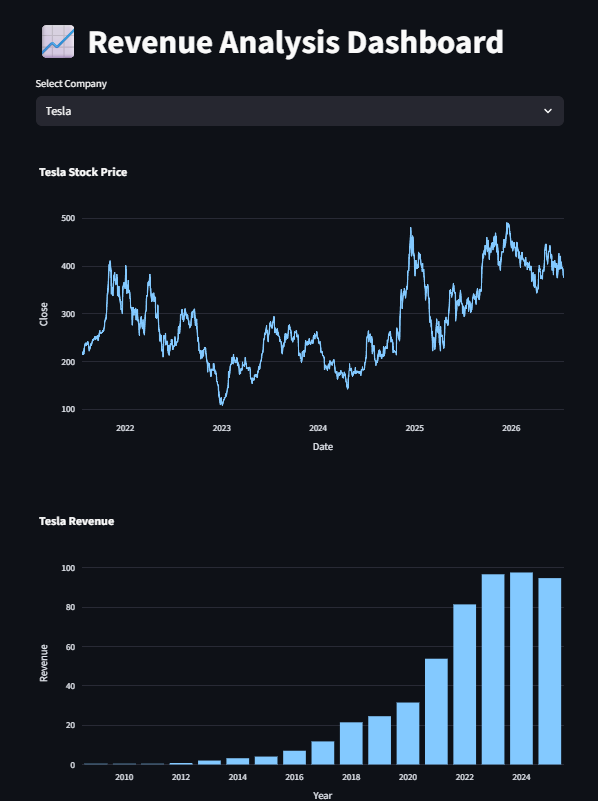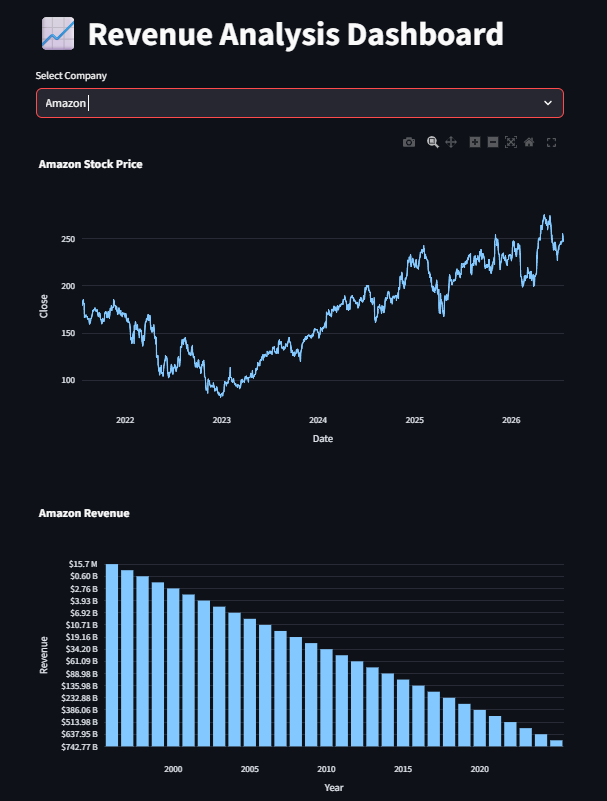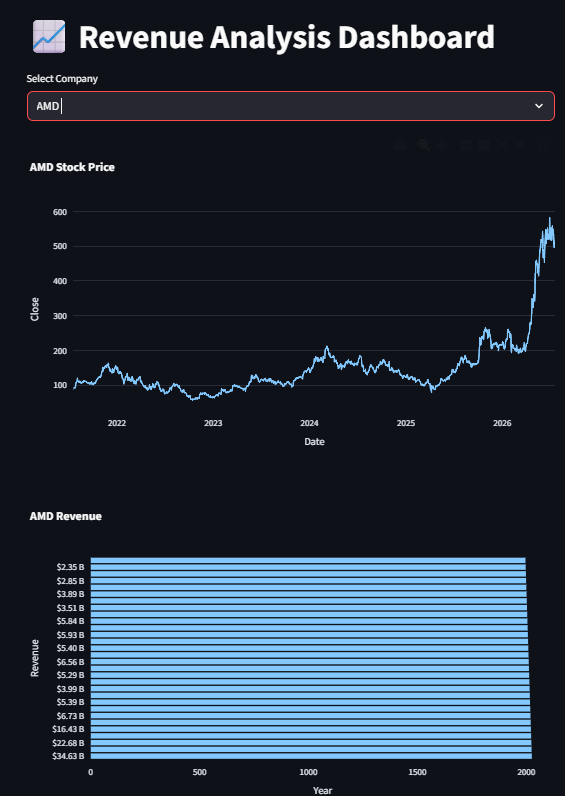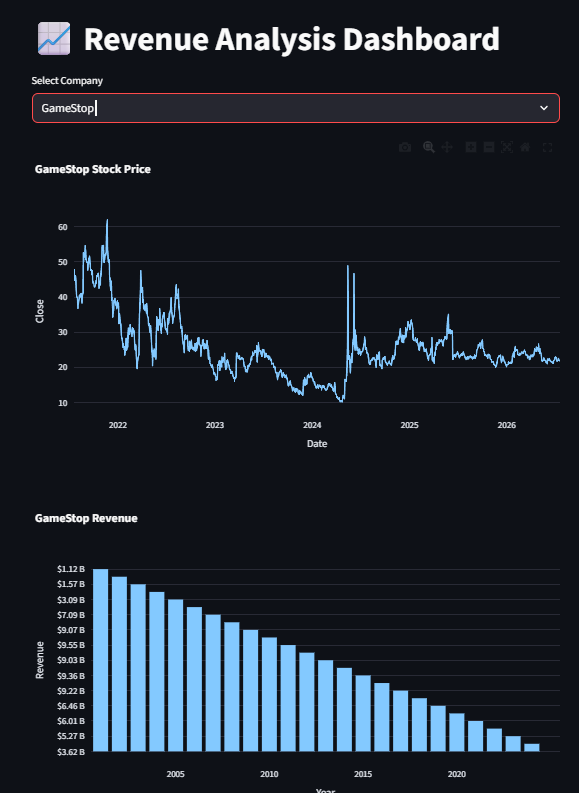

**Install libraries**

In [ ]:
!pip install yfinance beautifulsoup4 plotly

**Import libraries**

In [ ]:
import pandas as pd
import numpy as np

import yfinance as yf

import requests
from bs4 import BeautifulSoup

import matplotlib.pyplot as plt

import plotly.graph_objects as go
from plotly.subplots import make_subplots

import warnings
warnings.filterwarnings("ignore")

**Stock Data Collection Using yFinance**

In [ ]:
def get_stock_data(ticker):

    stock = yf.Ticker(ticker)

    data = stock.history(
        period="5y"
    )

    data.reset_index(inplace=True)

    return data

In [ ]:
#Tesla example
tesla_stock = get_stock_data("TSLA")

tesla_stock.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2021-07-20 00:00:00-04:00,217.330002,220.796661,213.500000,220.166672,46461300,0.0,0.0
1,2021-07-21 00:00:00-04:00,219.869995,221.619995,216.763336,218.429993,41859900,0.0,0.0
2,2021-07-22 00:00:00-04:00,218.813339,220.723328,214.866669,216.419998,45317100,0.0,0.0
3,2021-07-23 00:00:00-04:00,215.453339,216.266663,212.433334,214.460007,43814700,0.0,0.0
4,2021-07-26 00:00:00-04:00,216.990005,222.733337,215.703339,219.206665,76009800,0.0,0.0


In [ ]:
#Download all companies
companies = {
    "Tesla":"TSLA",
    "Amazon":"AMZN",
    "AMD":"AMD",
    "GameStop":"GME"
}


stock_data = {}

for company, ticker in companies.items():

    stock_data[company] = get_stock_data(ticker)


stock_data["Tesla"].head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2021-07-20 00:00:00-04:00,217.330002,220.796661,213.500000,220.166672,46461300,0.0,0.0
1,2021-07-21 00:00:00-04:00,219.869995,221.619995,216.763336,218.429993,41859900,0.0,0.0
2,2021-07-22 00:00:00-04:00,218.813339,220.723328,214.866669,216.419998,45317100,0.0,0.0
3,2021-07-23 00:00:00-04:00,215.453339,216.266663,212.433334,214.460007,43814700,0.0,0.0
4,2021-07-26 00:00:00-04:00,216.990005,222.733337,215.703339,219.206665,76009800,0.0,0.0


**Stock Data Information**

In [ ]:
tesla_stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype                           
---  ------        --------------  -----                           
 0   Date          1255 non-null   datetime64[ns, America/New_York]
 1   Open          1255 non-null   float64                         
 2   High          1255 non-null   float64                         
 3   Low           1255 non-null   float64                         
 4   Close         1255 non-null   float64                         
 5   Volume        1255 non-null   int64                           
 6   Dividends     1255 non-null   float64                         
 7   Stock Splits  1255 non-null   float64                         
dtypes: datetime64[ns, America/New_York](1), float64(6), int64(1)
memory usage: 78.6 KB


In [ ]:
tesla_stock.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,1255.0,2.842647e+02,8.708701e+01,1.030000e+02,2.183133e+02,2.625500e+02,3.509067e+02,4.898800e+02
High,1255.0,2.903286e+02,8.853265e+01,1.117500e+02,2.225067e+02,2.680400e+02,3.585283e+02,4.988300e+02
Low,1255.0,2.778636e+02,8.529969e+01,1.018100e+02,2.133483e+02,2.575200e+02,3.424483e+02,4.853300e+02
Close,1255.0,2.841608e+02,8.690448e+01,1.081000e+02,2.184700e+02,2.625900e+02,3.499900e+02,4.898800e+02
Volume,1255.0,9.572798e+07,3.988150e+07,5.643103e+06,6.657910e+07,8.876510e+07,1.156409e+08,3.065906e+08
Dividends,1255.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Stock Splits,1255.0,2.390438e-03,8.468362e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+00


**Stock Price Visualization**

In [ ]:
fig = go.Figure()


fig.add_trace(
    go.Scatter(
        x=tesla_stock["Date"],
        y=tesla_stock["Close"],
        name="Closing Price"
    )
)


fig.update_layout(
    title="Tesla Stock Price History",
    xaxis_title="Date",
    yaxis_title="Price ($)"
)


fig.show()

**Revenue Data Web Scraping**

Example Source:

companiesmarketcap.com

In [ ]:
def get_revenue(company):

    url = f"https://companiesmarketcap.com/{company}/revenue/"

    response = requests.get(url)

    soup = BeautifulSoup(
        response.text,
        "html.parser"
    )


    table = soup.find("table")


    df = pd.read_html(
        str(table)
    )[0]


    return df

**Extract Revenue Data**


In [ ]:
revenue_data = {}


for company in companies:

    name = company.lower()

    revenue_data[company] = get_revenue(name)


revenue_data["Tesla"].head()

,Year,Revenue,Change
0,2026 (TTM),$97.87 B,3.22%
1,2025,$94.82 B,-2.93%
2,2024,$97.69 B,0.95%
3,2023,$96.77 B,18.8%
4,2022,$81.46 B,51.35%


**Revenue Data Cleaning**

In [ ]:
tesla_revenue = revenue_data["Tesla"]


tesla_revenue.columns

tesla_revenue.head()

,Year,Revenue,Change
0,2026 (TTM),$97.87 B,3.22%
1,2025,$94.82 B,-2.93%
2,2024,$97.69 B,0.95%
3,2023,$96.77 B,18.8%
4,2022,$81.46 B,51.35%


In [ ]:
#Convert Revenue values
tesla_revenue["Revenue"] = (
    tesla_revenue["Revenue"]
    .astype(str)
    .str.replace("$","")
    .str.replace("B","")
    .astype(float)
)

**Revenue Visualization**

In [ ]:
fig = go.Figure()


fig.add_trace(
    go.Bar(
        x=tesla_revenue["Year"],
        y=tesla_revenue["Revenue"],
        name="Revenue"
    )
)


fig.update_layout(
    title="Tesla Revenue Growth",
    xaxis_title="Year",
    yaxis_title="Revenue (Billion $)"
)


fig.show()

**Create Dashboard Function**

In [ ]:
def create_dashboard(stock, revenue, company):


    fig = make_subplots(
        rows=2,
        cols=1,
        subplot_titles=[
            "Historical Stock Price",
            "Revenue Growth"
        ]
    )


    fig.add_trace(
        go.Scatter(
            x=stock["Date"],
            y=stock["Close"],
            name="Stock Price"
        ),
        row=1,
        col=1
    )


    fig.add_trace(
        go.Bar(
            x=revenue["Year"],
            y=revenue["Revenue"],
            name="Revenue"
        ),
        row=2,
        col=1
    )


    fig.update_layout(
        height=800,
        title=f"{company} Financial Dashboard"
    )


    fig.show()

In [ ]:
#Run Dashboard
create_dashboard(
    stock_data["Tesla"],
    revenue_data["Tesla"],
    "Tesla"
)

**Save CSV files**

In [ ]:
# Save Stock Data

stock_data["Tesla"].to_csv("tesla_stock.csv", index=False)
stock_data["Amazon"].to_csv("amazon_stock.csv", index=False)
stock_data["AMD"].to_csv("amd_stock.csv", index=False)
stock_data["GameStop"].to_csv("gamestop_stock.csv", index=False)


# Save Revenue Data

revenue_data["Tesla"].to_csv("tesla_revenue.csv", index=False)
revenue_data["Amazon"].to_csv("amazon_revenue.csv", index=False)
revenue_data["AMD"].to_csv("amd_revenue.csv", index=False)
revenue_data["GameStop"].to_csv("gamestop_revenue.csv", index=False)

# **Business Insights**

## Tesla
- Revenue increased significantly over the analyzed period.
- Stock price growth reflects investor confidence.

## Amazon
- Strong revenue growth shows business expansion.

## AMD
- Revenue changes influenced market performance.

## GameStop
- Stock price showed higher volatility compared with revenue trends.

# **Conclusion**

This project demonstrates:

- Financial data collection using APIs
- Web scraping techniques
- Data cleaning and preprocessing
- Exploratory data analysis
- Interactive dashboard development

Tools Used:

Python | Pandas | Plotly | BeautifulSoup | yFinance

NameError: name 'revenue' is not defined